# Testing the model on real data: BTC and ETH on Binance

Notebooks 01 and 02 work entirely inside the model. This one asks whether the model's predictions hold up in a real market. We take a week of trades for BTC and ETH, calibrate the model on them, and compare what it predicts for a market maker (how often it is filled, how its inventory moves, what it earns) with what the same strategy would have earned against the actual order flow.

The model does not forecast prices or volatility: the mid price is a random walk whose volatility σ is an input. What it does predict, given its parameters, is the outcome of market making, and that is what we test.

## TL;DR

- **Data.** Binance spot aggTrades for BTCUSDT and ETHUSDT, 23–29 September 2026. The market maker re-quotes once a second around the last trade price, a quote is filled when an aggressive trade reaches it, and each episode lasts 10 minutes.
- **The fill model works.** The probability that a quote is reached falls off exponentially with its distance from the price over most of the relevant range, though not at the touch and not in the far tail. Calibrated on the same day, the model predicts the number of fills to within 11% on every day.
- **The profit prediction fails, because of adverse selection.** The paper's model predicts that market making is profitable every day. In the backtest both strategies lose money every day, on average 8–17 standard errors away from the prediction. After a fill the price moves permanently against the market maker, by about \$16 for BTC and \$0.55 for ETH: two to three times the spread it earned.
- **Real data sides with the "all order flow moves the price" view of adverse selection.** Each fill costs one full ε for both strategies (1.01ε on average). Notebook 02's single-dealer model, in which inventory control halves that cost, predicts the symmetric strategy's mean PnL to within about one standard error but is far too optimistic for A-S. Charging a full ε per fill instead predicts both strategies' mean PnL to within about one standard error.
- **Risk is understated.** Even with ε, the model predicts only 37–38% of the actual standard deviation of A-S's PnL and 57–72% of the symmetric strategy's. One-second price changes are extremely fat-tailed, and volatility swings within the day and between weekdays and the weekend.
- **Forecasting needs frequent recalibration.** Parameters calibrated on the previous day give hourly PnL forecasts that are uncorrelated with the outcome; calibrating on the previous hour raises the correlation to 0.5–0.6.
- **Inventory control still pays, but only in risk.** A-S loses about as much as the symmetric strategy, with less than half its standard deviation.

## 1. Data

Binance publishes daily archives of every spot trade at [data.binance.vision](https://data.binance.vision). We use the *aggTrades* files. Each row is one aggressive order's fill at one price level, with the price, quantity, timestamp (in microseconds) and whether the buyer or the seller was the aggressor. The archives contain no quotes, so the price at any moment is proxied by the last trade price. The error this introduces is at most half the bid–ask spread, which on these books is usually a single one-cent tick (for BTC, about half of all aggressive buys print exactly one tick above the preceding aggressive sell). That is far below the quote distances used below: several dollars for BTC and tens of cents for ETH.

The data files are not stored in the repository. To reproduce, run `python scripts/download_binance.py BTCUSDT ETHUSDT --start 2026-09-23 --end 2026-09-29` from the project root. It downloads about 150 MB and verifies the SHA-256 checksums.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from mmsim import Params, AvellanedaStoikov, Symmetric, exact_moments
from mmsim.empirical import (Seconds, load_aggtrades, to_seconds, fill_probability, fit_intensity, backtest,
                             adverse_move)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 200)

SYMBOLS = ["BTCUSDT", "ETHUSDT"]
DAYS = [f"2026-09-{d}" for d in range(23, 30)]
T = 600      # episode length: 10 minutes of 1-second steps
GT = 0.6     # dimensionless risk aversion gamma * sigma^2 * T * k; the paper's gamma = 0.1 case has 0.6
DELTAS = {"BTCUSDT": np.arange(0.5, 40.01, 0.5), "ETHUSDT": np.arange(0.02, 2.001, 0.02)}   # quote distances (USD)

SEC, rows = {}, []
for sym in SYMBOLS:
    for d in DAYS:
        tr = load_aggtrades(f"data/binance/{sym}-aggTrades-{d}.zip")
        sec = SEC[sym, d] = to_seconds(tr)
        ds = sec.s_end - sec.s
        rows.append({"symbol": sym, "day": f"{d[5:]} {pd.Timestamp(d).day_name()[:3]}", "aggTrades": len(tr),
                     "mean price": tr.price.mean(), "seconds with a trade (%)": 100 * np.unique(np.floor(tr.t)).size / 86400,
                     "sigma (USD per sqrt s)": ds.std(), "kurtosis of 1-s changes": np.mean((ds - ds.mean())**4) / ds.var()**2})
pd.DataFrame(rows).set_index(["symbol", "day"]).round(2)

aggTrades  mean price  seconds with a trade (%)  sigma (USD per sqrt s)  kurtosis of 1-s changes
symbol  day                                                                                                        
BTCUSDT 09-23 Wed    1063008    85346.15                     92.41                    4.56                    61.75
        09-24 Thu     988460    84074.24                     89.40                    4.45                    88.90
        09-25 Fri     888686    84145.32                     88.98                    4.03                    51.38
        09-26 Sat     413820    84064.89                     91.51                    1.67                   224.10
        09-27 Sun     478532    84629.51                     85.91                    2.28                   130.99
        09-28 Mon    1139140    83378.13                     92.81                    4.49                    40.05
        09-29 Tue     868924    83640.00                     90.50                    3.48                    35.65
ETHUSDT 09-23 Wed     957661     2705.02                     79.38                    0.22                    53.29
        09-24 Thu     813306     2674.38                     75.93                    0.20                    61.82
        09-25 Fri     657542     2694.29                     71.10                    0.18                    50.66
        09-26 Sat     218219     2687.47                     58.83                    0.08                   295.79
        09-27 Sun     331264     2697.24                     62.41                    0.11                   139.59
        09-28 Mon     786830     2672.09                     77.17                    0.20                    25.07
        09-29 Tue     705188     2697.42                     74.04                    0.18                    29.02

- Both books are busy: BTC trades in 86–93% of all seconds, ETH in 59–79%.
- The weekend (Saturday 26 and Sunday 27) is much quieter, with a quarter to a half as many trades and roughly half the volatility of a weekday.
- One-second price changes are extremely fat-tailed: kurtosis 25–90 on weekdays and 130–300 at the weekend, against 3 for a normal distribution (and 1 for the model's ±σ√dt steps).

## 2. From trades to the model

| | Model | Backtest on real trades |
|---|---|---|
| Time step | dt = 1 s | the market maker re-quotes once a second |
| Horizon | T = 600 s | the day is cut into 144 ten-minute episodes; each starts flat and marks its inventory at the last price at the end |
| Mid price | random walk with volatility σ | last trade price |
| Fills | each side independently, with probability $A e^{-k\delta}dt$ | the ask is filled if an aggressive buy prints at or above it during the second, the bid if an aggressive sell prints at or below it; one unit, at the quoted price |
| Adverse selection | none (paper), or a jump of ε after each fill (notebook 02) | whatever the data contain |

Calibration uses one stretch of data (a day, or an hour in Section 6):

- **σ**: the standard deviation of one-second changes of the last trade price;
- **A, k**: a least-squares fit of $\log P(\delta) = \log A - k\delta$ to the empirical probability that a quote at distance δ is reached within one second (bids and asks averaged, fitted where $10^{-3} < P < 0.5$);
- **ε**: the average move of the price against the market maker over the 60 seconds after its own fills, measured by backtesting the strategy on the calibration data;
- **risk aversion**: γ is set so that $\gamma\sigma^2Tk = 0.6$, the dimensionless value of the paper's γ = 0.1 case. The strategy's inventory skew is then as large, relative to its spread, as in the paper.

The backtest is a best case in three ways: it ignores queue position (a quote is filled as soon as a trade reaches its price), our orders never move the market, and there are no fees. `mmsim.empirical.backtest` uses the same accounting as the simulator, and on data generated by the model itself it reproduces the exact solution (a unit test), so the disagreements below come from the data, not from the code.

In [2]:
def calibrate(sec, sym):
    """Model parameters from a stretch of data: sigma from 1-s price changes, (A, k) from the fill-probability curve."""
    pa, pb = fill_probability(sec, DELTAS[sym])
    A, k = fit_intensity(DELTAS[sym], (pa + pb) / 2)
    sigma = float(np.std(sec.s_end - sec.s))
    return Params(s0=float(sec.s[0]), T=T, dt=1.0, sigma=sigma, A=A, k=k, noise="gaussian")

def strategies(p):
    gamma = GT / (p.sigma**2 * p.T * p.k)
    return {"A-S": AvellanedaStoikov(gamma), "symmetric": Symmetric.matching(gamma, p)}

CAL, BT, EPS, rows = {}, {}, {}, []
for (sym, d), sec in SEC.items():
    p = CAL[sym, d] = calibrate(sec, sym)
    for name, strat in strategies(p).items():
        BT[sym, d, name] = backtest(strat, sec, p, log_trades=True)
        EPS[sym, d, name] = adverse_move(sec, BT[sym, d, name].trades, T, 60)
    rows.append({"symbol": sym, "day": d[5:], "sigma (USD per sqrt s)": p.sigma, "A (per s)": p.A, "k (per USD)": p.k,
                 "1/k (USD)": 1 / p.k, "gamma x 10^4": 1e4 * GT / (p.sigma**2 * T * p.k),
                 "eps, A-S fills (USD)": EPS[sym, d, "A-S"], "eps, symmetric fills (USD)": EPS[sym, d, "symmetric"]})
pd.DataFrame(rows).set_index(["symbol", "day"]).round(3)

sigma (USD per sqrt s)  A (per s)  k (per USD)  1/k (USD)  gamma x 10^4  eps, A-S fills (USD)  eps, symmetric fills (USD)
symbol  day                                                                                                                             
BTCUSDT 09-23                   4.557      0.093        0.131      7.623         3.671                17.229                      18.883
        09-24                   4.455      0.112        0.152      6.594         3.323                17.069                      20.158
        09-25                   4.027      0.083        0.143      6.988         4.309                19.275                      21.031
        09-26                   1.675      0.023        0.190      5.252        18.722                15.752                      16.175
        09-27                   2.285      0.043        0.190      5.263        10.085                15.392                      16.533
        09-28                   4.494      0.131        0.164      6.111         3.026                15.778                      16.950
        09-29                   3.476      0.110        0.192      5.211         4.313                16.072                      16.429
ETHUSDT 09-23                   0.220      0.119        3.050      0.328        67.757                 0.611                       0.650
        09-24                   0.196      0.146        3.829      0.261        67.834                 0.544                       0.602
        09-25                   0.182      0.104        3.472      0.288        86.743                 0.653                       0.722
        09-26                   0.079      0.035        5.060      0.198       313.129                 0.531                       0.531
        09-27                   0.113      0.057        4.367      0.229       177.773                 0.547                       0.542
        09-28                   0.203      0.172        3.955      0.253        61.280                 0.562                       0.615
        09-29                   0.183      0.177        4.555      0.220        65.392                 0.507                       0.526

- σ and A (how often quotes are reached) fall sharply on the weekend and move noticeably between weekdays; k, which sets how fast the fill probability falls with distance, moves less.
- ε is remarkably stable from day to day, and it is large: compare it with the natural quote distance 1/k.

## 3. Checking the assumptions

### 3.1 Fill probability vs distance

The model's fill intensity is $\lambda(\delta) = A e^{-k\delta}$. On a log scale that is a straight line. The figure shows the empirical probability that a quote at distance δ from the last trade price is reached within one second, for one day.

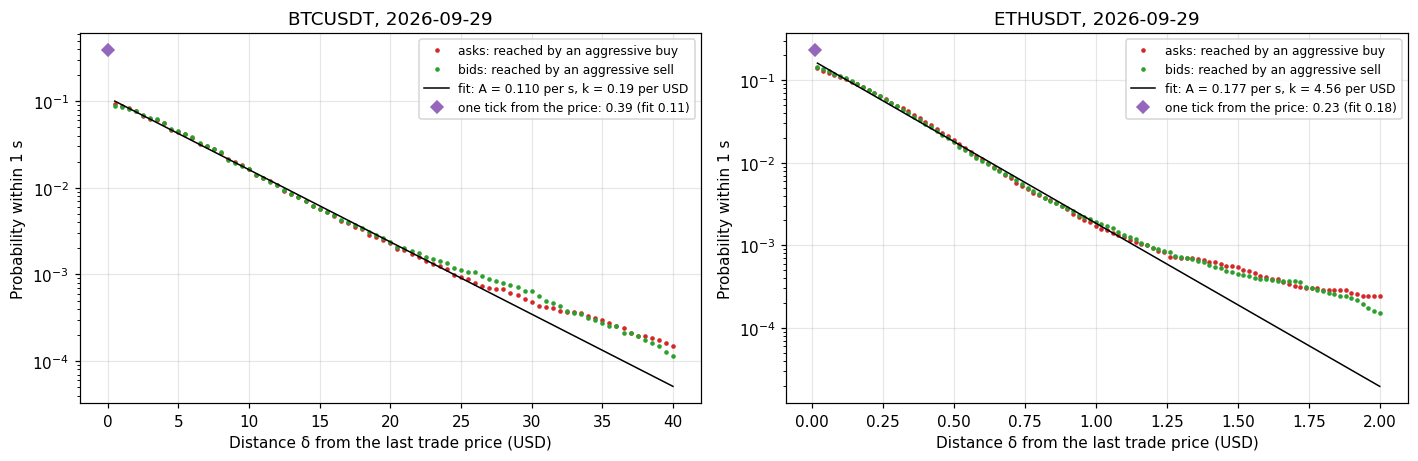

In [3]:
d = "2026-09-29"
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, sym in zip(axes, SYMBOLS):
    sec, p, x = SEC[sym, d], CAL[sym, d], DELTAS[sym]
    pa, pb = fill_probability(sec, x)
    touch = np.mean(fill_probability(sec, [0.01]))
    ax.semilogy(x, pa, ".", ms=4, color="tab:red", label="asks: reached by an aggressive buy")
    ax.semilogy(x, pb, ".", ms=4, color="tab:green", label="bids: reached by an aggressive sell")
    ax.semilogy(x, p.A * np.exp(-p.k * x), "k-", lw=1, label=f"fit: A = {p.A:.3f} per s, k = {p.k:.2f} per USD")
    ax.semilogy([0.01], [touch], "D", color="tab:purple", ms=6, label=f"one tick from the price: {touch:.2f} (fit {p.A:.2f})")
    ax.set_xlabel("Distance δ from the last trade price (USD)"); ax.set_ylabel("Probability within 1 s")
    ax.set_title(f"{sym}, {d}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Over most of the range the points lie on a straight line, so the exponential form holds, and bids and asks are almost identical. It fails at both ends. One tick from the price, a quote is reached more often than the fit says (3.5 times as often for BTC, 1.3 times for ETH), because almost any trade on that side reaches it. Far from the price the tail is fatter than exponential, because of large one-second moves. The strategies below quote in the middle of the range, where the fit is good.

### 3.2 Volatility is not constant

The model's σ is a constant. The figure shows hourly volatility of one-second price changes over the week, relative to each coin's weekly average.

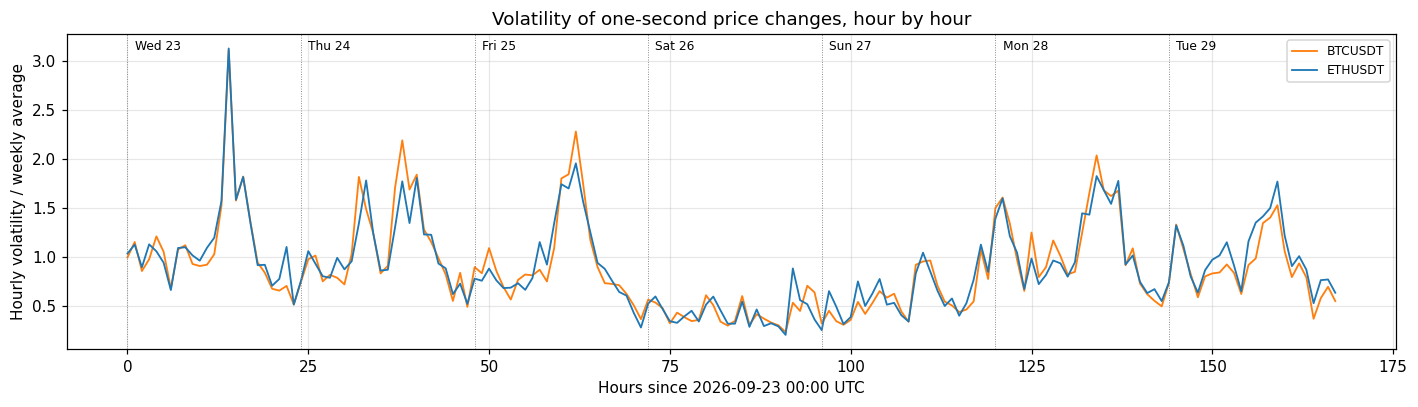

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.8))
for sym, c in zip(SYMBOLS, ["tab:orange", "tab:blue"]):
    ds = np.concatenate([SEC[sym, d].s_end - SEC[sym, d].s for d in DAYS])
    ax.plot(ds.reshape(-1, 3600).std(axis=1) / ds.std(), color=c, lw=1.2, label=sym)
for i, d in enumerate(DAYS):
    ax.axvline(24 * i, color="grey", lw=0.6, ls=":")
    ax.text(24 * i + 1, 0.95, pd.Timestamp(d).strftime("%a %d"), fontsize=8, transform=ax.get_xaxis_transform())
ax.set_xlabel("Hours since 2026-09-23 00:00 UTC"); ax.set_ylabel("Hourly volatility / weekly average")
ax.set_title("Volatility of one-second price changes, hour by hour"); ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

Volatility swings by a factor of four or more within a weekday, the two coins move together, and the weekend is quiet. Combined with the fat tails in Section 1, a constant σ can match the average variance of price changes, but not how that variance is spread across episodes.

### 3.3 Adverse selection

The paper's model assumes that a fill says nothing about the next price move. The figure measures the average move of the price against the A-S market maker after each of its fills, from the start of the second in which it was filled, together with the spread it earned per fill.

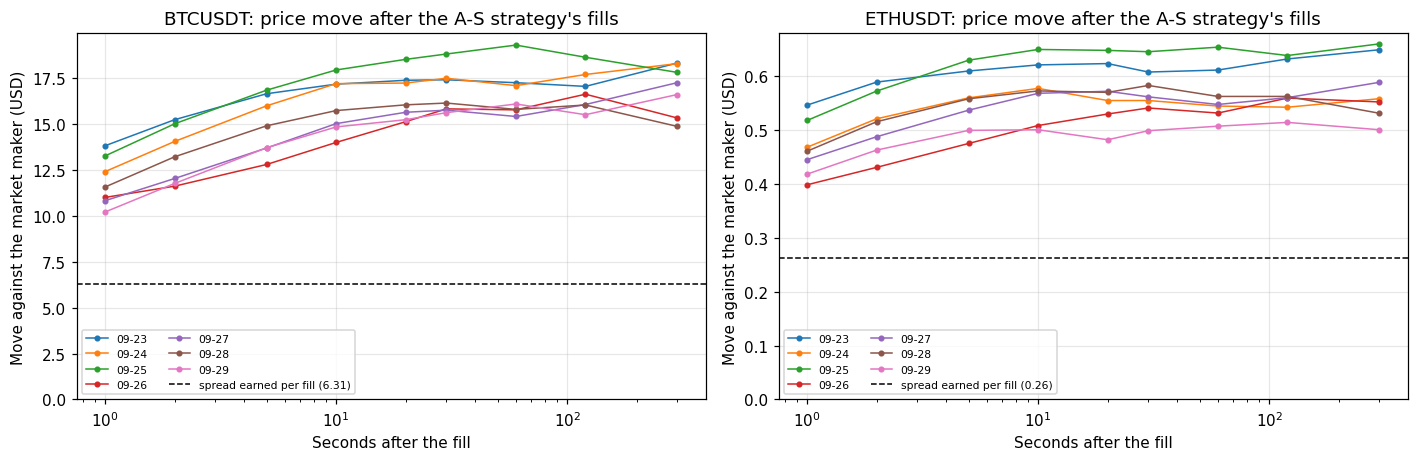

In [5]:
H = [1, 2, 5, 10, 20, 30, 60, 120, 300]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, sym in zip(axes, SYMBOLS):
    for d in DAYS:
        ax.plot(H, [adverse_move(SEC[sym, d], BT[sym, d, "A-S"].trades, T, h) for h in H], "o-", ms=3, lw=1, label=d[5:])
    earned = np.mean([BT[sym, d, "A-S"].spread_pnl.sum() / BT[sym, d, "A-S"].n_trades.sum() for d in DAYS])
    ax.axhline(earned, color="k", ls="--", lw=1, label=f"spread earned per fill ({earned:.2f})")
    ax.set_xscale("log"); ax.set_ylim(bottom=0)
    ax.set_xlabel("Seconds after the fill"); ax.set_ylabel("Move against the market maker (USD)")
    ax.set_title(f"{sym}: price move after the A-S strategy's fills"); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

The move is large, fast and permanent. Most of it happens within the second of the fill, since the fill itself usually happens because the price ran through the quote. It keeps growing for another 10–30 seconds and then stays. It is two to three times the spread earned per fill, so on average every fill loses money. In the terms of notebook 02, ε is large, and the same on every day.

## 4. Does the model predict market making?

Here each day is calibrated on itself and tested on itself. That removes any error from parameters drifting over time, so what remains comes from the model's structure. For each day and strategy the backtest is compared with three predictions of mean PnL:

- **paper model**: no adverse selection (ε = 0);
- **single-dealer ε**: notebook 02's model with the measured ε, in which only the market maker's own fills move the price;
- **ε per fill**: the spread capture predicted by the model minus ε times its predicted number of fills. This is what adverse selection costs when every aggressive order moves the price, whether or not it trades with us.

z is the prediction error in standard errors of the backtest mean (144 episodes a day). The first table averages over the seven days.

In [6]:
rows = []
for (sym, d), p in CAL.items():
    for name, strat in strategies(p).items():
        bt, eps = BT[sym, d, name], EPS[sym, d, name]
        ex0, ex_sd = exact_moments(strat, p), exact_moments(strat, p.with_(impact=eps))
        se = bt.pnl.std(ddof=1) / np.sqrt(bt.pnl.size)
        row = {"symbol": sym, "strategy": name, "day": d[5:],
               "fills: model / backtest": ex0["mean_trades"] / bt.n_trades.mean(),
               "std q_T: model / backtest": ex0["std_q"] / bt.q.std(ddof=1),
               "cost per fill / eps: backtest": -bt.inventory_pnl.mean() / bt.n_trades.mean() / eps,
               "cost per fill / eps: single-dealer model": (ex0["mean_pnl"] - ex_sd["mean_pnl"]) / ex0["mean_trades"] / eps,
               "std PnL: model / backtest": ex_sd["std_pnl"] / bt.pnl.std(ddof=1),
               "mean PnL (backtest)": bt.pnl.mean(), "SE": se}
        for m, v in [("paper model", ex0["mean_pnl"]), ("single-dealer eps", ex_sd["mean_pnl"]),
                     ("eps per fill", ex0["mean_pnl"] - eps * ex0["mean_trades"])]:
            row[f"mean PnL ({m})"] = v
            row[f"z ({m})"] = (v - bt.pnl.mean()) / se
        rows.append(row)
SAME = pd.DataFrame(rows).set_index(["symbol", "strategy", "day"]).sort_index()

summary_cols = ["fills: model / backtest", "std q_T: model / backtest", "cost per fill / eps: backtest",
                "cost per fill / eps: single-dealer model", "z (paper model)", "z (single-dealer eps)", "z (eps per fill)"]
display(SAME[summary_cols].groupby(level=["symbol", "strategy"]).mean().round(2))
SAME[["mean PnL (backtest)", "SE", "mean PnL (paper model)", "mean PnL (single-dealer eps)", "mean PnL (eps per fill)",
      "z (paper model)", "z (single-dealer eps)", "z (eps per fill)"]].round(1)

fills: model / backtest  std q_T: model / backtest  cost per fill / eps: backtest  cost per fill / eps: single-dealer model  z (paper model)  z (single-dealer eps)  \
symbol  strategy                                                                                                                                                                         
BTCUSDT A-S                           1.02                       0.88                           1.01                                      0.60            15.75                   6.33   
        symmetric                     0.95                       0.76                           1.01                                      0.97             7.64                   0.46   
ETHUSDT A-S                           1.00                       0.98                           1.01                                      0.58            17.11                   7.43   
        symmetric                     0.98                       0.83                           1.01                                      0.96             8.40                   0.16   

                   z (eps per fill)  
symbol  strategy                     
BTCUSDT A-S                   -0.08  
        symmetric              0.26  
ETHUSDT A-S                    0.07  
        symmetric             -0.18

mean PnL (backtest)     SE  mean PnL (paper model)  mean PnL (single-dealer eps)  mean PnL (eps per fill)  z (paper model)  z (single-dealer eps)  z (eps per fill)
symbol  strategy  day                                                                                                                                                                       
BTCUSDT A-S       09-23               -373.1   43.6                   291.9                         -83.1                   -355.7             15.3                    6.6               0.4
                  09-24               -529.3   53.7                   304.6                        -135.0                   -470.3             15.5                    7.3               1.1
                  09-25               -392.7   45.4                   240.5                        -140.7                   -410.0             14.0                    5.6              -0.4
                  09-26                -82.1    9.5                    50.7                         -49.6                    -94.9             14.0                    3.4              -1.3
                  09-27               -184.8   19.9                    93.5                         -74.7                   -172.1             14.0                    5.5               0.6
                  09-28               -544.0   51.5                   330.3                        -137.3                   -508.4             17.0                    7.9               0.7
                  09-29               -429.3   32.5                   237.4                        -171.4                   -482.1             20.5                    7.9              -1.6
        symmetric 09-23               -344.7  108.8                   308.2                        -336.9                   -356.4              6.0                    0.1              -0.1
                  09-24               -640.5  145.9                   321.8                        -504.0                   -534.3              6.6                    0.9               0.7
                  09-25               -449.8  104.8                   253.8                        -393.7                   -411.2              6.7                    0.5               0.4
                  09-26               -100.0   18.9                    52.8                         -88.2                    -89.2              8.1                    0.6               0.6
                  09-27               -187.9   40.2                    98.2                        -166.9                   -170.6              7.1                    0.5               0.4
                  09-28               -549.3   97.7                   349.1                        -458.5                   -493.4              9.2                    0.9               0.6
                  09-29               -388.3   65.4                   250.8                        -413.3                   -437.3              9.8                   -0.4              -0.7
ETHUSDT A-S       09-23                -14.2    1.6                    16.2                          -0.5                    -13.5             18.5                    8.3               0.5
                  09-24                -17.6    1.7                    15.7                          -2.0                    -16.5             19.1                    8.9               0.6
                  09-25                -14.6    1.7                    12.4                          -3.4                    -15.2             15.6                    6.5              -0.4
                  09-26                 -4.3    0.7                     2.9                          -2.0                     -4.7             10.5                    3.3              -0.5
                  09-27                 -7.4    0.9                     5.4                          -2.3                     -7.2             15.0                    5.9               0.2
                  09-28                -21.9    2.1     

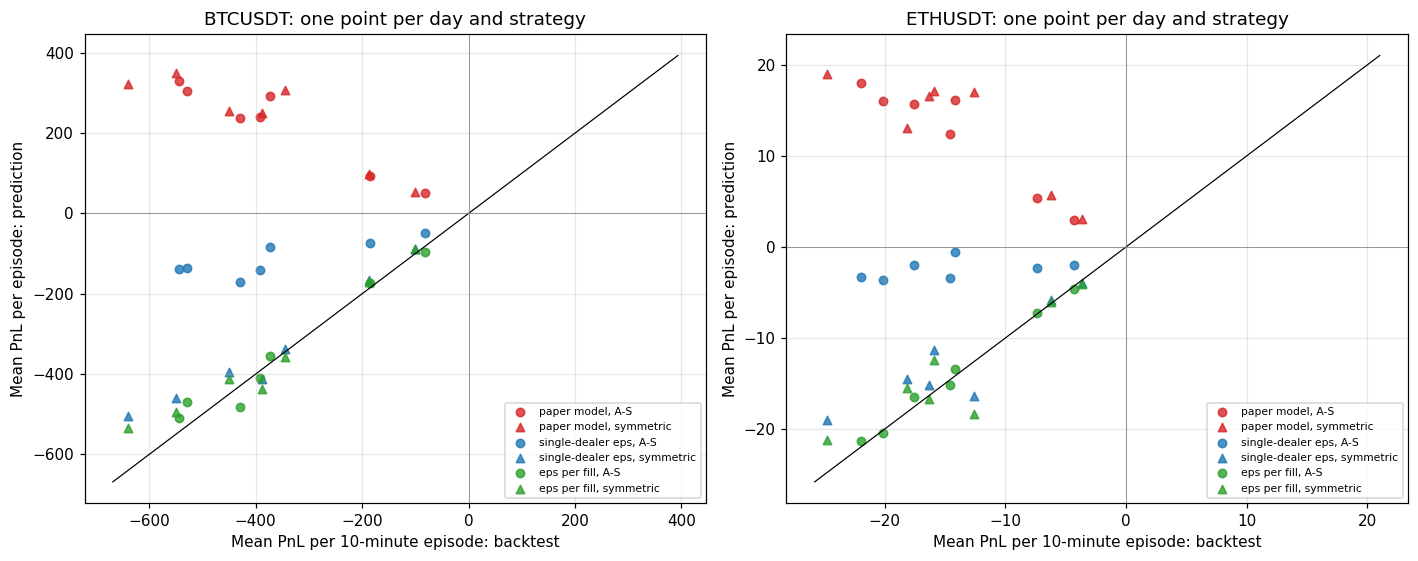

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
styles = {"paper model": "tab:red", "single-dealer eps": "tab:blue", "eps per fill": "tab:green"}
for ax, sym in zip(axes, SYMBOLS):
    for m, c in styles.items():
        for strat, marker in [("A-S", "o"), ("symmetric", "^")]:
            s = SAME.loc[(sym, strat)]
            ax.scatter(s["mean PnL (backtest)"], s[f"mean PnL ({m})"], marker=marker, color=c, s=30, alpha=0.8,
                       label=f"{m}, {strat}")
    lo, hi = min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], "k-", lw=0.8)
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set_xlabel("Mean PnL per 10-minute episode: backtest"); ax.set_ylabel("Mean PnL per episode: prediction")
    ax.set_title(f"{sym}: one point per day and strategy"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

- **Fills and inventory are predicted well.** The number of fills is within 11% of the backtest on every day. The model somewhat understates how far inventory wanders, most for the symmetric strategy.
- **The paper's model is badly wrong about profits.** It predicts a profit every day; the backtest loses every day. The errors are 8–17 standard errors on average.
- **In the backtest each fill costs one full ε, for both strategies.** Notebook 02's single-dealer model agrees for the symmetric strategy, whose inventory is a random walk, and it predicts that strategy's mean PnL to within about one standard error. For A-S it expects inventory control to cut the cost to about 0.6ε, and that does not happen, so its prediction for A-S is still far too optimistic.
- **Charging ε per fill** is accurate for both strategies: its errors average close to zero and exceed two standard errors for only one of the 28 day–strategy pairs. Here ε is measured on the same day, so this is partly an in-sample fit; Section 6 measures it on past data instead.

### 4.1 Why inventory control does not halve the cost

In notebook 02 the cost halves for A-S because the jump after an inventory-reducing fill moves the price in favour of the inventory that is left. That only works if moves after inventory-reducing fills are as large as those after inventory-increasing ones. The table splits the A-S strategy's fills by what they did to its inventory.

In [8]:
rows = []
for (sym, d), sec in SEC.items():
    tr = BT[sym, d, "A-S"].trades
    t = tr["path"] * T + tr["step"]
    price_at = np.r_[sec.s, sec.s_end[-1]]
    ok = t + 60 < price_at.size
    move = -tr["side"][ok] * (price_at[t[ok] + 60] - price_at[t[ok]])
    qb, side = tr["q_before"][ok], tr["side"][ok]
    kind = np.where(qb == 0, "from flat", np.where(np.sign(qb) == -side, "reduces |q|", "increases |q|"))
    dist = np.abs(tr["price"][ok] - tr["mid"][ok])
    for kd in ["reduces |q|", "from flat", "increases |q|"]:
        m = kind == kd
        rows.append({"symbol": sym, "fill": kd, "day": d, "share of fills": m.mean(),
                     "quote distance (USD)": dist[m].mean(), "move after 60 s (USD)": move[m].mean()})
cols = ["share of fills", "quote distance (USD)", "move after 60 s (USD)"]
pd.DataFrame(rows).groupby(["symbol", "fill"], sort=False)[cols].mean().round(3)

share of fills  quote distance (USD)  move after 60 s (USD)
symbol  fill                                                                      
BTCUSDT reduces |q|             0.458                 4.224                 13.548
        from flat               0.267                 7.222                 17.364
        increases |q|           0.274                 9.110                 21.281
ETHUSDT reduces |q|             0.472                 0.182                  0.493
        from flat               0.278                 0.303                  0.589
        increases |q|           0.250                 0.378                  0.679

They are not. A-S's inventory-reducing fills come from quotes close to the price and are followed by the smallest moves. Fills that build inventory come from quotes further out, which are reached only when the price runs, and are followed by the largest ones. The favourable moves after reducing fills are too small to pay back the unfavourable ones, so A-S pays about a full ε per fill, like the symmetric strategy.

This also answers the question notebook 02 left open about its own assumption. The data behave like a market where every aggressive order moves the price, not one where only the market maker's fills do.

## 5. Risk

Even with ε included, the model understates the standard deviation of PnL per episode:

In [9]:
SAME["std PnL: model / backtest"].groupby(level=["symbol", "strategy"]).agg(["mean", "min", "max"]).round(2)

mean   min   max
symbol  strategy                   
BTCUSDT A-S        0.37  0.29  0.57
        symmetric  0.57  0.44  0.78
ETHUSDT A-S        0.38  0.33  0.44
        symmetric  0.72  0.42  1.37

On average the model with ε predicts only 37–38% of the actual standard deviation for A-S, and 57–72% for the symmetric strategy. Three things are missing from it:
- fat tails;
- volatility that changes within the day, so some episodes are far more volatile than the daily average;
- the randomness of adverse selection itself: ε is an average, and individual fills are followed by moves of very different sizes, which matters most for A-S because its PnL is otherwise so stable.

## 6. Forecasting: day-ahead vs hour-ahead

So far each day was calibrated on itself. A real market maker has to calibrate on the past. We compare two schemes for the A-S strategy, with the ε-per-fill prediction of mean PnL:
- **day-ahead**: calibrate on the whole previous day;
- **hour-ahead**: calibrate on the previous hour.

Each scheme predicts the mean PnL and the number of fills per episode for each hour (hours 1–23 of each day; day-ahead starts on the second day), and is compared with the backtest of that hour. This cell takes a few minutes.

test hours  corr(predicted, actual): mean PnL  corr(predicted, actual): fills  typical factor error in fills  mean |error| of mean PnL
symbol  calibration                                                                                                                                        
BTCUSDT day-ahead           138                              -0.03                            0.01                           2.10                    295.56
        hour-ahead          161                               0.61                            0.68                           1.46                    192.44
ETHUSDT day-ahead           138                              -0.02                            0.10                           2.10                     11.37
        hour-ahead          161                               0.52                            0.70                           1.41                      8.85

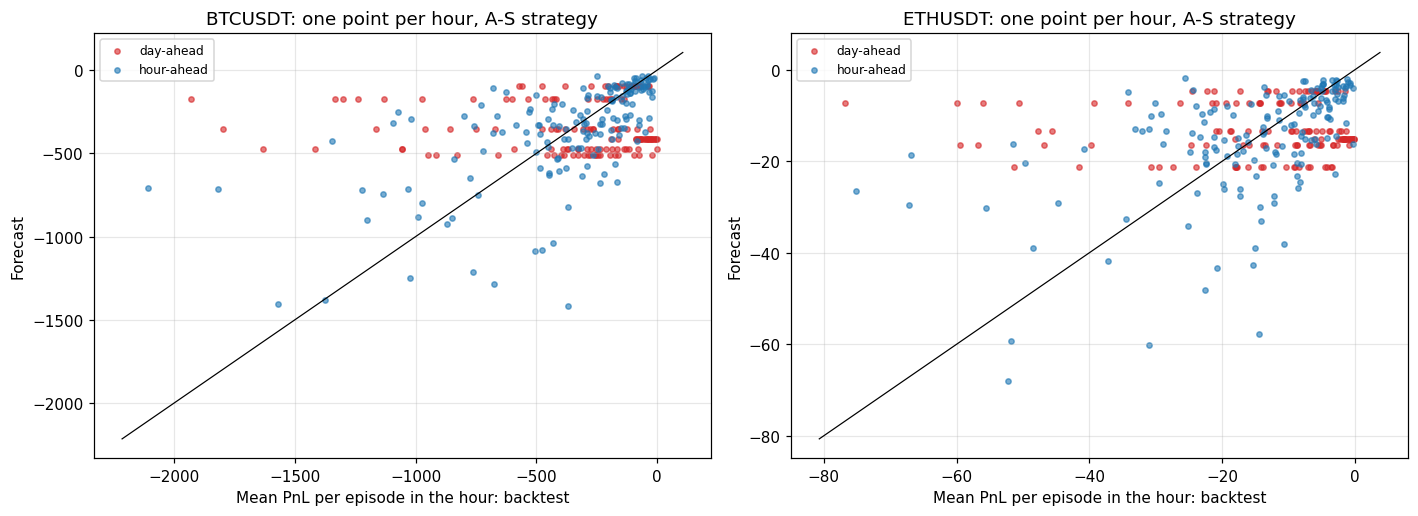

In [10]:
def cut(sec, a, b):
    return Seconds(s=sec.s[a:b], s_end=sec.s_end[a:b], hi=sec.hi[a:b], lo=sec.lo[a:b])

def forecast(p, sec):
    """A-S strategy calibrated on (p, sec), with its predicted mean PnL (eps per fill) and fills per episode."""
    strat = strategies(p)["A-S"]
    eps = adverse_move(sec, backtest(strat, sec, p, log_trades=True).trades, T, 60)
    ex = exact_moments(strat, p)
    return strat, ex["mean_pnl"] - eps * ex["mean_trades"], ex["mean_trades"]

HOUR, rows = 3600, []
for sym in SYMBOLS:
    for di, d in enumerate(DAYS):
        sec = SEC[sym, d]
        day_ahead = forecast(CAL[sym, DAYS[di - 1]], SEC[sym, DAYS[di - 1]]) if di > 0 else None
        for h in range(1, 24):
            past, test = cut(sec, (h - 1) * HOUR, h * HOUR), cut(sec, h * HOUR, (h + 1) * HOUR)
            p_hour = calibrate(past, sym)
            strat, pred, fills = forecast(p_hour, past)
            bt = backtest(strat, test, p_hour)
            row = {"symbol": sym, "day": d, "hour": h, "hour-ahead: predicted": pred, "hour-ahead: backtest": bt.pnl.mean(),
                   "hour-ahead: fills predicted": fills, "hour-ahead: fills": bt.n_trades.mean()}
            if day_ahead is not None:
                strat_d, pred_d, fills_d = day_ahead
                bt_d = backtest(strat_d, test, CAL[sym, DAYS[di - 1]])
                row.update({"day-ahead: predicted": pred_d, "day-ahead: backtest": bt_d.pnl.mean(),
                            "day-ahead: fills predicted": fills_d, "day-ahead: fills": bt_d.n_trades.mean()})
            rows.append(row)
FC = pd.DataFrame(rows)

stats = []
for sym in SYMBOLS:
    for how in ["day-ahead", "hour-ahead"]:
        f = FC[FC.symbol == sym].dropna(subset=[f"{how}: predicted"])
        fills_err = np.abs(np.log(f[f"{how}: fills predicted"] / f[f"{how}: fills"]))
        stats.append({"symbol": sym, "calibration": how, "test hours": len(f),
                      "corr(predicted, actual): mean PnL": np.corrcoef(f[f"{how}: predicted"], f[f"{how}: backtest"])[0, 1],
                      "corr(predicted, actual): fills": np.corrcoef(f[f"{how}: fills predicted"], f[f"{how}: fills"])[0, 1],
                      "typical factor error in fills": np.exp(np.median(fills_err)),
                      "mean |error| of mean PnL": np.mean(np.abs(f[f"{how}: predicted"] - f[f"{how}: backtest"]))})
display(pd.DataFrame(stats).set_index(["symbol", "calibration"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, sym in zip(axes, SYMBOLS):
    f = FC[FC.symbol == sym]
    for how, c in [("day-ahead", "tab:red"), ("hour-ahead", "tab:blue")]:
        ax.scatter(f[f"{how}: backtest"], f[f"{how}: predicted"], s=12, color=c, alpha=0.6, label=how)
    lo, hi = min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], "k-", lw=0.8)
    ax.set_xlabel("Mean PnL per episode in the hour: backtest"); ax.set_ylabel("Forecast")
    ax.set_title(f"{sym}: one point per hour, A-S strategy"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

A day-ahead forecast is a single number for the whole day, so it cannot tell busy hours from quiet ones, and its correlation with the hourly outcome is about zero. Recalibrating every hour tracks activity: the forecasts' correlation with the outcome is 0.5–0.6 for mean PnL and 0.7 for the number of fills, and the typical error in the number of fills falls from a factor of 2.1 to about 1.4. For forecasting, how recently the model was calibrated matters more than the model's finer details.

## 7. Inventory control in reality

Pooling all episodes of the week:

In [11]:
rows = []
for sym in SYMBOLS:
    for name in ["A-S", "symmetric"]:
        pnl = np.concatenate([BT[sym, d, name].pnl for d in DAYS])
        rows.append({"symbol": sym, "strategy": name, "episodes": pnl.size, "mean PnL per episode": pnl.mean(),
                     "std PnL": pnl.std(ddof=1), "fills per episode": np.mean([BT[sym, d, name].n_trades.mean() for d in DAYS]),
                     "std q_T": np.concatenate([BT[sym, d, name].q for d in DAYS]).std(ddof=1)})
pd.DataFrame(rows).set_index(["symbol", "strategy"]).round(2)

episodes  mean PnL per episode  std PnL  fills per episode  std q_T
symbol  strategy                                                                      
BTCUSDT A-S            1008               -362.19   500.98              34.34     2.95
        symmetric      1008               -380.07  1120.79              34.78     7.33
ETHUSDT A-S            1008                -14.30    19.61              48.00     2.79
        symmetric      1008                -13.95    49.02              45.84     7.79

A-S and the symmetric strategy lose about the same amount, but A-S's PnL has less than half the standard deviation, and its inventory stays much closer to zero. The paper's central trade-off survives in real data only in its risk half: inventory control reduces risk, but it does not protect against adverse selection.

## 8. Summary and limitations

**Findings:**
1. The model's fill mechanism is realistic over the range of quote distances that matter: the exponential fill curve fits, and the number of fills is predicted to within 11% on every day (calibrated on the same day).
2. The paper's model predicts profits where the backtest loses money every day, because it has no adverse selection. After a fill, the price moves permanently against the market maker by two to three times the spread earned.
3. In the data, every fill costs one full ε, for the inventory-averse strategy as much as for the symmetric one. This supports models where all aggressive order flow moves the price, rather than notebook 02's single-dealer model, and charging ε per fill predicts mean PnL well.
4. The model understates risk: it predicts 37–72% of the actual standard deviation of PnL, because it misses fat tails, intraday volatility and noisy adverse selection.
5. For forecasting, recalibrating every hour is far better than using the previous day's parameters.

**Limitations:**
- Prices are proxied by the last trade; the archives have no quotes.
- The fill rule ignores queue position and assumes that our orders change nothing. Both make the backtest optimistic.
- There are no fees. At a typical retail maker fee of 0.1% of notional (about \$80 per BTC and \$3 per ETH at these prices), every fill would lose far more than the spread it earns. Quoting at these distances only makes sense with zero or negative (rebate) maker fees.
- The quotes sit several ticks away from the price. Real market makers mostly compete at the touch, where queue position, rather than the model's fill curve, decides who trades.
- One week, two coins, one exchange, spot only.
- "ε per fill" gives only the mean. A full model in which every aggressive order moves the price would also give the risk and the certainty equivalent. That, time-varying σ and A, and the dynamic-programming optimal quotes are the natural next steps.